# SankhyaVox — SVM Classifier Training

Train and evaluate the SVM (RBF kernel) baseline on augmented data, test on held-out human speaker.

**Prerequisites:** Run `DataPipeline().build()` and augmentation first.

In [1]:
# ── stdlib ──
import pickle
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple

# ── third-party ──
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Config

In [2]:
# ── Paths ──
DATA_PROCESSED = "/kaggle/input/datasets/devarabhavana/sankhyavox-dataset/data_processed"
PROCESSED_DIR  = DATA_PROCESSED          # alias used by SankhyaVoxDataset default
CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Human speaker to hold out for testing
TEST_SPEAKER = "S05"

## SankhyaVoxDataset

**Paste the `SankhyaVoxDataset` class from `dataset/dataset.py` below.**

In [3]:
class SankhyaVoxDataset:
    """
    Unified dataset for SankhyaVox training and evaluation.

    Reads ``<processed_dir>/human.csv``, ``tts.csv``, ``augmented.csv``
    and concatenates them into a single DataFrame.

    Parameters
    ----------
    processed_dir : Path or str, optional
        Root of the processed data tree.  Default: ``config.PROCESSED_DIR``.
    categories : list of str, optional
        Which categories to load.  Default: all CSVs present on disk.

    ``ds[i]`` returns::

        {
            "audio_path":   str,      # path to source .wav segment
            "audio_source": str,      # "human" | "tts" | "augmented"
            "speaker_id":   str,      # e.g. "S01"
            "token":        str,      # Sanskrit label, e.g. "eka"
            "label":        int,      # numeric value, e.g. 1
            "feature":      ndarray,  # shape (n_frames, 39)
        }
    """

    CATEGORIES = ("human", "tts", "augmented")

    def __init__(
        self,
        processed_dir: Optional[Path] = None,
        categories: Optional[List[str]] = None,
    ):
        self._root = (Path(processed_dir) if processed_dir else PROCESSED_DIR).resolve()
        self._categories = categories or list(self.CATEGORIES)
        self._df = self._load_csvs()

    # ── Loading ───────────────────────────────────────────────────────────

    def _load_csvs(self) -> pd.DataFrame:
        """Load and concatenate category CSV files."""
        frames = []
        for cat in self._categories:
            csv_path = self._root / f"{cat}.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df["category"] = cat
                frames.append(df)

        if not frames:
            return pd.DataFrame()

        return pd.concat(frames, ignore_index=True)

    # ── Properties ────────────────────────────────────────────────────────

    @property
    def df(self) -> pd.DataFrame:
        """Full metadata DataFrame."""
        return self._df

    @property
    def speakers(self) -> List[str]:
        """Sorted list of unique speaker IDs."""
        if self._df.empty:
            return []
        return sorted(self._df["speaker"].unique().tolist())

    @property
    def tokens(self) -> List[str]:
        """Sorted list of unique Sanskrit token labels."""
        if self._df.empty:
            return []
        return sorted(self._df["sanskrit_label"].unique().tolist())

    # ── Indexing ──────────────────────────────────────────────────────────

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        """Return a sample dict for the given global index."""
        row = self._df.iloc[idx]
        npy_abs = str(self._root / row["npy_path"])
        wav_abs = str(self._root / row["wav_path"])
        return {
            "audio_path": wav_abs,
            "audio_source": row["category"],
            "speaker_id": row["speaker"],
            "token": row["sanskrit_label"],
            "label": int(row["label"]),
            "feature": np.load(npy_abs),
        }

    def __len__(self) -> int:
        return len(self._df)

    def __iter__(self) -> Iterator[Dict[str, Any]]:
        for i in range(len(self)):
            yield self[i]

    # ── Batch access ──────────────────────────────────────────────────────

    def get_Xy(self) -> Tuple[List[np.ndarray], List[int]]:
        """Return ``(features_list, labels_list)`` for model training."""
        X, y = [], []
        for i in range(len(self)):
            s = self[i]
            X.append(s["feature"])
            y.append(s["label"])
        return X, y

    # ── Filtering / Splitting ─────────────────────────────────────────────

    def filter(
        self,
        category: Optional[str] = None,
        speaker: Optional[str] = None,
        label: Optional[int] = None,
    ) -> "SankhyaVoxDataset":
        """Return a new dataset filtered by the given criteria."""
        mask = pd.Series(True, index=self._df.index)
        if category is not None:
            mask &= self._df["category"] == category
        if speaker is not None:
            mask &= self._df["speaker"] == speaker
        if label is not None:
            mask &= self._df["label"] == label

        filtered = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
        filtered._root = self._root
        filtered._categories = self._categories
        filtered._df = self._df[mask].reset_index(drop=True)
        return filtered

    def exclude_speakers(
        self, speakers_to_exclude: List[str]
    ) -> "SankhyaVoxDataset":
        """Return a new dataset excluding the given speaker IDs."""
        mask = ~self._df["speaker"].isin(speakers_to_exclude)
        ds = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
        ds._root = self._root
        ds._categories = self._categories
        ds._df = self._df[mask].reset_index(drop=True)
        return ds

    def split_by_speakers(
        self,
        train: List[str],
        val: List[str],
        test: List[str],
    ) -> Tuple["SankhyaVoxDataset", "SankhyaVoxDataset", "SankhyaVoxDataset"]:
        """Split dataset into train / val / test by speaker IDs."""

        def _subset(spk_list: List[str]) -> "SankhyaVoxDataset":
            ds = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
            ds._root = self._root
            ds._categories = self._categories
            ds._df = self._df[self._df["speaker"].isin(spk_list)].reset_index(
                drop=True
            )
            return ds

        return _subset(train), _subset(val), _subset(test)

    # ── Display ───────────────────────────────────────────────────────────

    def __repr__(self) -> str:
        cats = self._df["category"].value_counts().to_dict() if len(self._df) else {}
        cat_str = ", ".join(f"{k}={v}" for k, v in sorted(cats.items()))
        return f"SankhyaVoxDataset(samples={len(self)}, {cat_str})"

    def summary(self) -> str:
        """Return a detailed formatted summary of the dataset contents.

        For each category present, prints a table with speakers as columns,
        tokens as rows, and sample counts as cell values plus a Total column.
        Then prints a consolidated table aggregating across all speakers per
        category.
        """
        if self._df.empty:
            return repr(self) + "\n  (no samples loaded)"

        lines = [repr(self)]
        lines.append(f"  Speakers: {', '.join(self.speakers)}")
        lines.append(f"  Tokens:   {', '.join(self.tokens)}")
        lines.append("")

        # Build token display labels: "token (label)"
        token_label_map = (
            self._df[["sanskrit_label", "label"]]
            .drop_duplicates()
            .sort_values("label")
        )
        ordered_tokens = token_label_map["sanskrit_label"].tolist()
        token_display = {
            row.sanskrit_label: f"{row.sanskrit_label} ({row.label})"
            for row in token_label_map.itertuples()
        }

        # ── Per-category detail tables ────────────────────────────────────
        for cat in self.CATEGORIES:
            sub = self._df[self._df["category"] == cat]
            if sub.empty:
                continue

            speakers = sorted(sub["speaker"].unique())
            lines.append(f"  ┌─ {cat.upper()} ({len(sub)} samples, "
                         f"{len(speakers)} speakers) ─────────")

            # Build cross-tab: rows=token, cols=speaker
            ct = pd.crosstab(sub["sanskrit_label"], sub["speaker"])
            # Ensure all tokens and speakers present
            ct = ct.reindex(index=ordered_tokens, columns=speakers, fill_value=0)
            ct["Total"] = ct.sum(axis=1)

            # Format header
            row_label_width = max(len(d) for d in token_display.values()) + 2
            col_width = max(max((len(s) for s in speakers), default=5), 5) + 1
            total_width = max(5, len("Total")) + 1

            header = "  " + "".rjust(row_label_width)
            for sp in speakers:
                header += sp.rjust(col_width)
            header += "Total".rjust(total_width)
            lines.append(header)
            lines.append("  " + "─" * (row_label_width + col_width * len(speakers) + total_width))

            for tok in ordered_tokens:
                display = token_display[tok]
                row_str = "  " + display.rjust(row_label_width)
                for sp in speakers:
                    row_str += str(ct.at[tok, sp]).rjust(col_width)
                row_str += str(ct.at[tok, "Total"]).rjust(total_width)
                lines.append(row_str)

            # Column totals
            lines.append("  " + "─" * (row_label_width + col_width * len(speakers) + total_width))
            totals_row = "  " + "Total".rjust(row_label_width)
            for sp in speakers:
                totals_row += str(int(ct[sp].sum())).rjust(col_width)
            totals_row += str(int(ct["Total"].sum())).rjust(total_width)
            lines.append(totals_row)
            lines.append("")

        # ── Consolidated table across categories ──────────────────────────
        cats_present = [c for c in self.CATEGORIES if c in self._df["category"].values]
        if len(cats_present) > 1:
            lines.append("  ┌─ CONSOLIDATED (all categories) ─────────")

            ct_all = pd.crosstab(self._df["sanskrit_label"], self._df["category"])
            ct_all = ct_all.reindex(index=ordered_tokens, columns=cats_present, fill_value=0)
            ct_all["Total"] = ct_all.sum(axis=1)

            row_label_width = max(len(d) for d in token_display.values()) + 2
            cat_width = max(max((len(c) for c in cats_present), default=9), 9) + 1
            total_width = max(5, len("Total")) + 1

            header = "  " + "".rjust(row_label_width)
            for c in cats_present:
                header += c.rjust(cat_width)
            header += "Total".rjust(total_width)
            lines.append(header)
            lines.append("  " + "─" * (row_label_width + cat_width * len(cats_present) + total_width))

            for tok in ordered_tokens:
                display = token_display[tok]
                row_str = "  " + display.rjust(row_label_width)
                for c in cats_present:
                    row_str += str(ct_all.at[tok, c]).rjust(cat_width)
                row_str += str(ct_all.at[tok, "Total"]).rjust(total_width)
                lines.append(row_str)

            lines.append("  " + "─" * (row_label_width + cat_width * len(cats_present) + total_width))
            totals_row = "  " + "Total".rjust(row_label_width)
            for c in cats_present:
                totals_row += str(int(ct_all[c].sum())).rjust(cat_width)
            totals_row += str(int(ct_all["Total"].sum())).rjust(total_width)
            lines.append(totals_row)
            lines.append("")

        return "\n".join(lines)

## Load Data & Split

In [4]:
# Training: augmented data, excluding held-out speaker
aug_ds = SankhyaVoxDataset(DATA_PROCESSED, categories=["augmented"])
print(f"Full augmented: {repr(aug_ds)}")
print(f"Augmented speakers: {aug_ds.speakers}")

# Exclude the test speaker's augmented variant
aug_test_speaker = f"aug{TEST_SPEAKER}"  # e.g. "augS05"
train_ds = aug_ds.exclude_speakers([aug_test_speaker])
X_train, y_train = train_ds.get_Xy()
print(f"\nTrain: {len(X_train)} samples (excluded {aug_test_speaker})")

# Testing: real human recordings for held-out speaker
human_ds = SankhyaVoxDataset(DATA_PROCESSED, categories=["human"])
test_ds = human_ds.filter(speaker=TEST_SPEAKER)
X_test, y_test = test_ds.get_Xy()
print(f"Test:  {len(X_test)} samples (human {TEST_SPEAKER})")
print(f"Labels in test: {sorted(set(y_test))}")
print(f"Feature shape example: {X_train[0].shape}")

print("=" * 70)
print("TRAIN DATA SUMMARY:")
print("=" * 70)
print(train_ds.summary())
print()

print("=" * 70)
print("TEST DATA SUMMARY:")
print("=" * 70)
print(test_ds.summary())
print()

Full augmented: SankhyaVoxDataset(samples=10962, augmented=10962)
Augmented speakers: ['augS01', 'augS02', 'augS03', 'augS04', 'augS05', 'augTTS01', 'augTTS02', 'augTTS03', 'augTTS04']

Train: 9423 samples (excluded augS05)
Test:  171 samples (human S05)
Labels in test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 100]
Feature shape example: (79, 39)
TRAIN DATA SUMMARY:
SankhyaVoxDataset(samples=9423, augmented=9423)
  Speakers: augS01, augS02, augS03, augS04, augTTS01, augTTS02, augTTS03, augTTS04
  Tokens:   ashta, catur, dasha, dvi, eka, nava, pancha, sapta, shat, shata, shunya, tri, vimsati

  ┌─ AUGMENTED (9423 samples, 8 speakers) ─────────
                   augS01   augS02   augS03   augS04 augTTS01 augTTS02 augTTS03 augTTS04 Total
  ────────────────────────────────────────────────────────────────────────────────────────────
      shunya (0)      108       90       90       90       90       90       90       90   738
         eka (1)      117       90       90       90       90     

---
## SVM Classifier

**Paste the `SVMClassifier` class from `models/svm_classifier.py` below.**

In [5]:
class SVMClassifier:
    """
    SVM baseline with RBF kernel and optional grid search.

    Parameters
    ----------
    kernel : str
        SVM kernel type.
    C : float, optional
        Regularisation parameter.  If ``None``, tuned via grid search.
    gamma : float or str, optional
        Kernel coefficient.  If ``None``, tuned via grid search.
    checkpoint_path : str or Path, optional
        If given, load a previously saved model.
    """

    def __init__(
        self,
        kernel: str = "rbf",
        C: Optional[float] = None,
        gamma: Optional[float] = None,
        checkpoint_path: Optional[str] = None,
    ):
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.scaler = StandardScaler()
        self.model: Optional[SVC] = None

        if checkpoint_path:
            self.load(checkpoint_path)

    @staticmethod
    def _transform(features: np.ndarray) -> np.ndarray:
        """
        Transform variable-length MFCC (n_frames, 39) to a fixed-length vector.

        Computes per-coefficient: mean, std, min, max, median, 10th and
        90th percentiles, inter-quartile range, and mean absolute
        frame-to-frame change.  Plus normalised log frame count as a
        duration proxy.
        Output: 39 * 9 + 1 = 352 dimensions.

        Rationale: SVMs with RBF kernels measure pairwise distances in
        feature space.  Richer statistics (percentile tails, IQR, delta
        magnitude) spread class-discriminative information across more
        dimensions so the RBF kernel can find better separating surfaces.
        The log-frame-count encodes utterance duration, which differs
        substantially across tokens (e.g. "dvi" is short, "vimsati" is
        long) and is a strong discriminative cue.
        """
        mean = features.mean(axis=0)
        std = features.std(axis=0)
        fmin = features.min(axis=0)
        fmax = features.max(axis=0)
        med = np.median(features, axis=0)
        q10 = np.percentile(features, 10, axis=0)
        q90 = np.percentile(features, 90, axis=0)
        iqr = np.percentile(features, 75, axis=0) - np.percentile(features, 25, axis=0)
        if len(features) > 1:
            delta_abs_mean = np.abs(np.diff(features, axis=0)).mean(axis=0)
        else:
            delta_abs_mean = np.zeros(features.shape[1])
        n_frames = np.array([np.log1p(len(features))])
        return np.concatenate([
            mean, std, fmin, fmax, med, q10, q90, iqr, delta_abs_mean, n_frames,
        ])

    def fit(
        self,
        X: list[np.ndarray],
        y: list[int],
        grid_search: bool = True,
        cv: int = 3,
    ) -> "SVMClassifier":
        """
        Fit the SVM with optional grid search.

        Parameters
        ----------
        X : list of ndarray, each (n_frames, feat_dim)
        y : list of int labels
        grid_search : bool
            If True and C/gamma are None, run grid search.
        cv : int
            Cross-validation folds for grid search.
        """
        data = np.array([self._transform(feat) for feat in X])
        labels = np.array(y)
        data = self.scaler.fit_transform(data)

        if grid_search and (self.C is None or self.gamma is None):
            param_grid = {
                "C": [0.01, 0.1, 1, 10, 100, 1000],
                "gamma": [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1],
            }
            gs = GridSearchCV(
                SVC(kernel=self.kernel),
                param_grid,
                cv=cv,
                scoring="accuracy",
                n_jobs=-1,
                verbose=1,
            )
            gs.fit(data, labels)

            # Report all candidate results
            results = pd.DataFrame(gs.cv_results_)
            results = results.sort_values("rank_test_score")
            print("\nGrid Search Results (all candidates):")
            print("-" * 60)
            for _, row in results.iterrows():
                print(f"  C={row['param_C']:<8}  gamma={row['param_gamma']:<10}  "
                      f"mean_acc={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}  "
                      f"rank={int(row['rank_test_score'])}")
            print("-" * 60)

            self.model = gs.best_estimator_
            self.C = gs.best_params_["C"]
            self.gamma = gs.best_params_["gamma"]
            print(f"Best: C={self.C}, gamma={self.gamma}, "
                  f"acc={gs.best_score_:.3f}")
        else:
            self.model = SVC(
                kernel=self.kernel,
                C=self.C or 1.0,
                gamma=self.gamma or "scale",
            )
            self.model.fit(data, labels)

        return self

    def predict(self, X: list[np.ndarray]) -> np.ndarray:
        """Predict class labels for a list of feature sequences."""
        assert self.model is not None, "Model not fitted yet. Call fit() first."
        data = np.array([self._transform(feat) for feat in X])
        data = self.scaler.transform(data)
        return self.model.predict(data)

    def save(self, path: str) -> None:
        """Save model + scaler to a pickle file."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump({
                "kernel": self.kernel, "C": self.C, "gamma": self.gamma,
                "scaler": self.scaler, "model": self.model,
            }, f)
        print(f"Saved SVMClassifier -> {path}")

    def load(self, path: str) -> None:
        """Load model + scaler from a pickle file."""
        with open(path, "rb") as f:
            data = pickle.load(f)
        self.kernel = data["kernel"]
        self.C = data["C"]
        self.gamma = data["gamma"]
        self.scaler = data["scaler"]
        self.model = data["model"]
        print(f"Loaded SVMClassifier <- {path}")


## Train

In [6]:
svm = SVMClassifier()
svm.fit(X_train, y_train, grid_search=True, cv=3)
print(f"Best params: C={svm.C}, gamma={svm.gamma}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Grid Search Results (all candidates):
------------------------------------------------------------
  C=100.0     gamma=0.001       mean_acc=0.5418 ± 0.0735  rank=1
  C=1000.0    gamma=0.001       mean_acc=0.5418 ± 0.0735  rank=1
  C=10.0      gamma=0.001       mean_acc=0.5417 ± 0.0735  rank=3
  C=1.0       gamma=0.001       mean_acc=0.5375 ± 0.0744  rank=4
  C=10.0      gamma=0.0001      mean_acc=0.5152 ± 0.0725  rank=5
  C=100.0     gamma=0.0001      mean_acc=0.5123 ± 0.0730  rank=6
  C=1000.0    gamma=0.0001      mean_acc=0.5113 ± 0.0726  rank=7
  C=100.0     gamma=1e-05       mean_acc=0.5101 ± 0.0745  rank=8
  C=1000.0    gamma=1e-05       mean_acc=0.5070 ± 0.0717  rank=9
  C=10.0      gamma=0.01        mean_acc=0.4538 ± 0.0504  rank=10
  C=1000.0    gamma=0.01        mean_acc=0.4538 ± 0.0504  rank=10
  C=100.0     gamma=0.01        mean_acc=0.4538 ± 0.0504  rank=10
  C=1.0       gamma=0.01        mean_acc=0.4531 ± 0.047

## Save

In [7]:
svm.save(str(CHECKPOINT_DIR / "svm_classifier.pkl"))

Saved SVMClassifier -> checkpoints/svm_classifier.pkl


## Load

In [8]:
svm_loaded = SVMClassifier(checkpoint_path=str(CHECKPOINT_DIR / "svm_classifier.pkl"))

Loaded SVMClassifier <- checkpoints/svm_classifier.pkl


## Test

In [9]:
svm_preds = svm_loaded.predict(X_test)
svm_acc = accuracy_score(y_test, svm_preds)
print(f"SVM Accuracy: {svm_acc:.3f}")
print()
print(classification_report(y_test, svm_preds, zero_division=0))

SVM Accuracy: 0.474

              precision    recall  f1-score   support

           0       0.72      1.00      0.84        13
           1       0.67      0.40      0.50        10
           2       0.11      0.20      0.14        10
           3       0.75      0.43      0.55        14
           4       0.58      1.00      0.73        15
           5       0.00      0.00      0.00        12
           6       0.71      0.71      0.71        14
           7       0.33      0.31      0.32        13
           8       1.00      0.33      0.50        15
           9       1.00      0.25      0.40        12
          10       0.56      0.42      0.48        12
          20       0.54      0.82      0.65        17
         100       0.00      0.00      0.00        14

    accuracy                           0.47       171
   macro avg       0.54      0.45      0.45       171
weighted avg       0.55      0.47      0.46       171



## Results

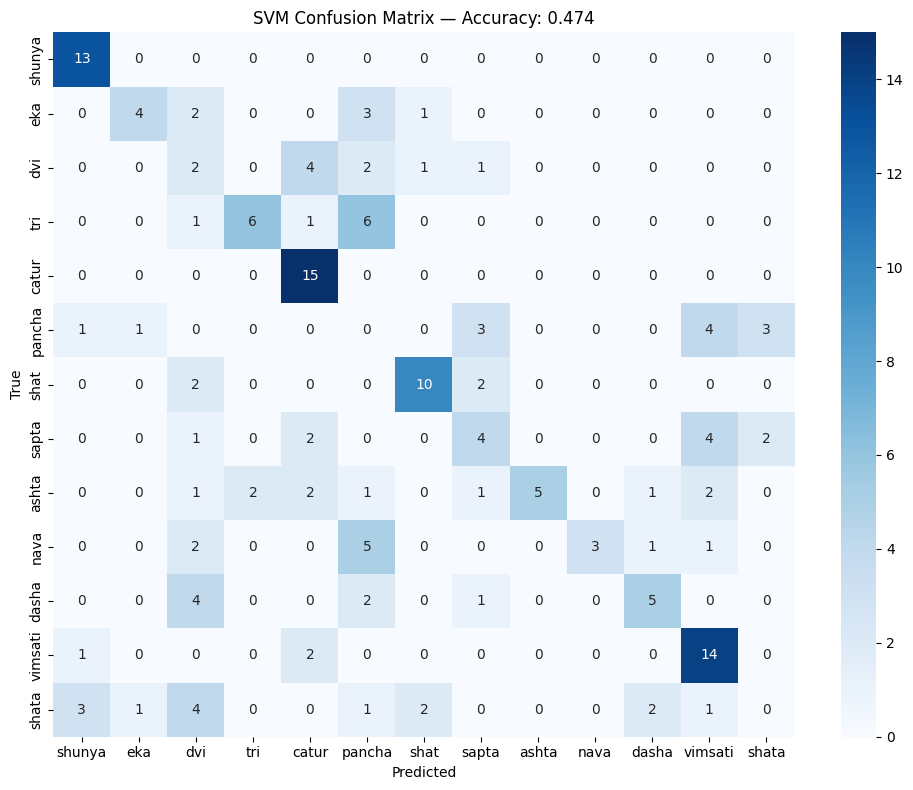


Per-class accuracy:
    shunya (  0): 13/13 = 100.00%
       eka (  1): 4/10 = 40.00%
       dvi (  2): 2/10 = 20.00%
       tri (  3): 6/14 = 42.86%
     catur (  4): 15/15 = 100.00%
    pancha (  5): 0/12 = 0.00%
      shat (  6): 10/14 = 71.43%
     sapta (  7): 4/13 = 30.77%
     ashta (  8): 5/15 = 33.33%
      nava (  9): 3/12 = 25.00%
     dasha ( 10): 5/12 = 41.67%
   vimsati ( 20): 14/17 = 82.35%
     shata (100): 0/14 = 0.00%


In [10]:
VALUE_TO_TOKEN = {
    0: "shunya", 1: "eka", 2: "dvi", 3: "tri", 4: "catur",
    5: "pancha", 6: "shat", 7: "sapta", 8: "ashta", 9: "nava",
    10: "dasha", 20: "vimsati", 100: "shata",
}

labels_sorted = sorted(set(y_test))
label_names = [VALUE_TO_TOKEN.get(l, str(l)) for l in labels_sorted]

cm = confusion_matrix(y_test, svm_preds, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=label_names, yticklabels=label_names)
ax.set_title(f"SVM Confusion Matrix \u2014 Accuracy: {svm_acc:.3f}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, l in enumerate(labels_sorted):
    row_total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / row_total if row_total > 0 else 0
    print(f"  {VALUE_TO_TOKEN.get(l, str(l)):>8s} ({l:>3d}): {correct}/{row_total} = {acc:.2%}")